# This notebook contains the EDA of the financial fraud dataset from Kaggle

In [1]:
#%pip install -r ../requirements.txt -q

In [ ]:
import kagglehub
import os
import shutil

# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

Dataset downloaded to: C:\Users\lylyl\.cache\kagglehub\datasets\sriharshaeedala\financial-fraud-detection-dataset\versions\1


In [6]:
import pandas as pd
import os

csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
print(f'\n')
print("Shape:", df.shape)
print(f'\n')
print(df.head())
print(f'\n')
print(df.info())


Looking for file at: ../data/raw/financial-fraud-detection-dataset\Synthetic_Financial_datasets_log.csv


Shape: (6362620, 11)


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0    

Temporary [for faster uploading]

In [1]:
import os

target_dir = "../data/raw/financial-fraud-detection-dataset"
csv_file = os.path.join(target_dir, "Synthetic_Financial_datasets_log.csv")

In [3]:
import pandas as pd

df = pd.read_csv(csv_file)
df.shape

MemoryError: Unable to allocate 48.5 MiB for an array with shape (1, 6362620) and data type object

## Initial Data Exploration

Checking for missing values in the data

In [4]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Check for duplicates

In [5]:
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

# Check for conditional duplicates
dup_subset = df[df.duplicated(subset=['step','nameOrig', 'nameDest'], keep=False)]
print(f"Potential duplicate transactions (same step, sender, receiver): {dup_subset.shape[0]}")

dup_subset = df[df.duplicated(subset=['nameOrig', 'nameDest', 'type'], keep=False)]
print(f"Potential duplicate transactions (same sender, receiver, type): {dup_subset.shape[0]}")

dup_subset = df[df.duplicated(subset=['nameOrig', 'nameDest'], keep=False)]
print(f"Potential duplicate transactions (same sender, receiver): {dup_subset.shape[0]}")


Number of duplicate rows: 0
Potential duplicate transactions (same step, sender, receiver): 0
Potential duplicate transactions (same sender, receiver, type): 0
Potential duplicate transactions (same sender, receiver): 0


Identify accounts appearing both as nameOrig and nameDest

In [53]:
senders = set(df['nameOrig'].unique())
receivers = set(df['nameDest'].unique())


overlap_accounts = senders.intersection(receivers)

print(f"Total unique senders: {len(senders)}")
print(f"Total unique receivers: {len(receivers)}")
print(f"Accounts appearing as both sender and receiver: {len(overlap_accounts)}")
print(f'\n')


suspicious_df = df[df['nameOrig'].isin(overlap_accounts) | df['nameDest'].isin(overlap_accounts)]

Total unique senders: 6353307
Total unique receivers: 2722362
Accounts appearing as both sender and receiver: 1769




Rate of transactions involve overlapping accounts

In [7]:
total_txn = df.shape[0]
overlap_txn = suspicious_df.shape[0]
print(f"Percentage of transactions involving dual-role accounts: {(overlap_txn / total_txn) * 100:.2f}%")

# Fraud rate among overlapping accounts
fraud_overlap = suspicious_df['isFraud'].sum()
fraud_rate_overlap = fraud_overlap / suspicious_df.shape[0]
overall_fraud_rate = df['isFraud'].mean()

print(f"Fraud rate (overlap accounts): {fraud_rate_overlap:.4f}")
print(f"Overall fraud rate (entire dataset): {overall_fraud_rate:.4f}")

Percentage of transactions involving dual-role accounts: 0.24%
Fraud rate (overlap accounts): 0.0012
Overall fraud rate (entire dataset): 0.0013


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

1. Transaction type insights

Transaction type distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud rate by type:
type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64


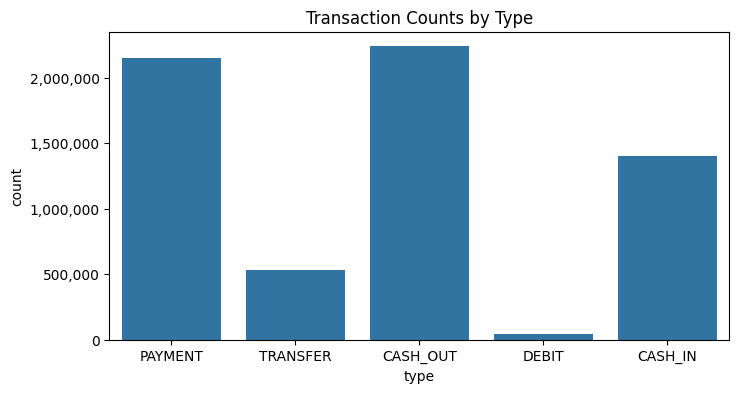

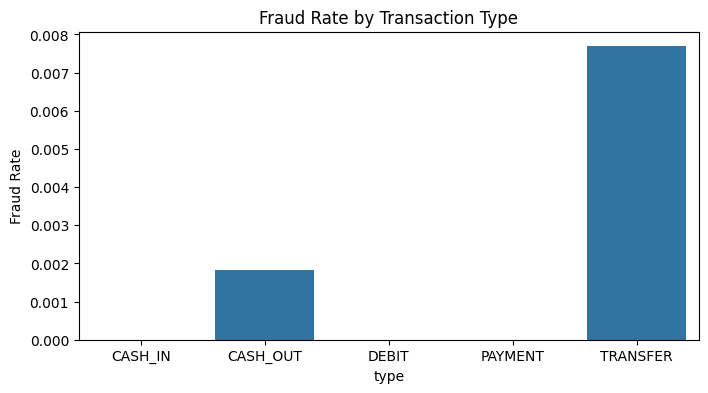

In [9]:
print("Transaction type distribution:")
print(df['type'].value_counts())
print("\nFraud rate by type:")
print(df.groupby('type')['isFraud'].mean())

plt.figure(figsize=(8,4))
ax = sns.countplot(x='type', data=df)
ax.ticklabel_format(style='plain', axis='y') 
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.title("Transaction Counts by Type")
plt.show()

plt.figure(figsize=(8,4))
fraud_rate_by_type = df.groupby('type')['isFraud'].mean()
sns.barplot(x=fraud_rate_by_type.index, y=fraud_rate_by_type.values)
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

2. Amount analysis

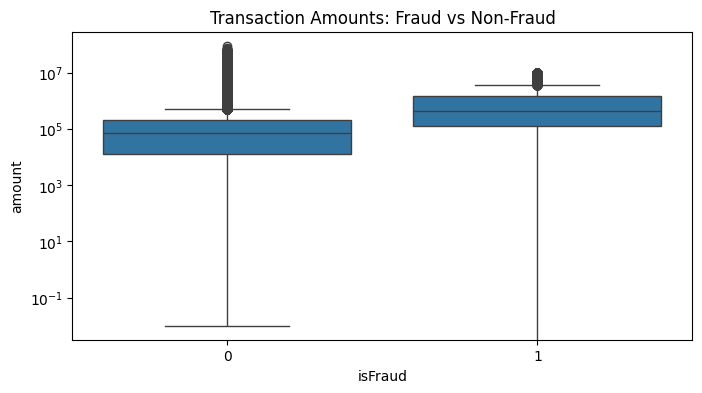


Amount summary (fraud vs non-fraud):
             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  


In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')  # amounts vary a lot
plt.title("Transaction Amounts: Fraud vs Non-Fraud")
plt.show()

print("\nAmount summary (fraud vs non-fraud):")
print(df.groupby('isFraud')['amount'].describe())

3. Sender / Receiver behavior


Transactions per sender (summary):
count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: count, dtype: float64

Top 10 senders by total amount:
nameOrig
C1715283297    92445516.64
C2127282686    73823490.36
C2044643633    71172480.42
C1425667947    69886731.30
C1584456031    69337316.27
C811810230     67500761.29
C420748282     66761272.21
C1139847449    64234448.19
C300140823     63847992.58
C372535854     63294839.63
Name: amount, dtype: float64


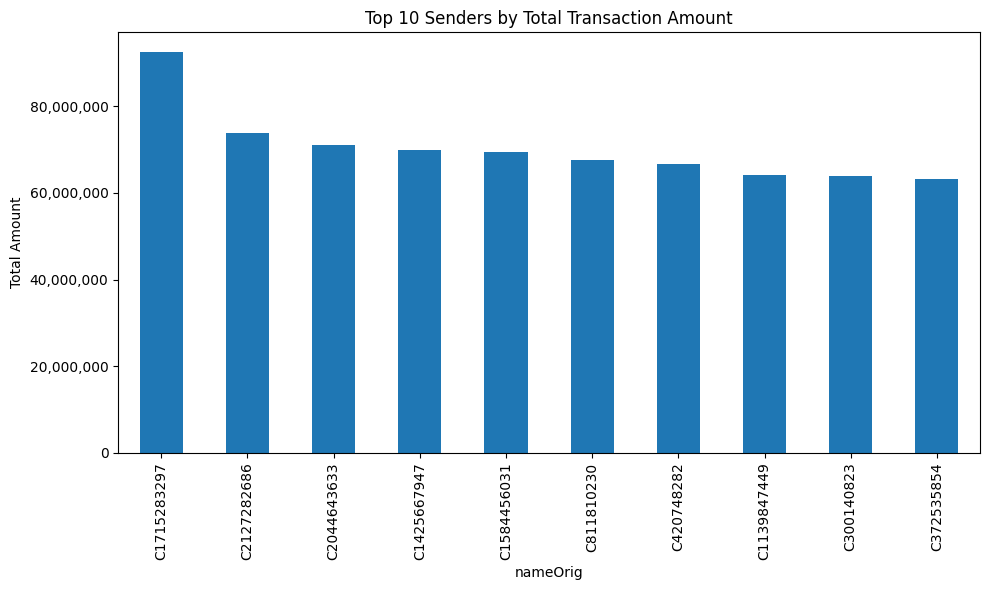

In [4]:
print("\nTransactions per sender (summary):")
print(df['nameOrig'].value_counts().describe())

top_senders = df.groupby('nameOrig')['amount'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 senders by total amount:")
print(top_senders)

ax = top_senders.plot(kind='bar', figsize=(10,6))
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax.set_title("Top 10 Senders by Total Transaction Amount")   # use set_title on the Axes
ax.set_ylabel("Total Amount")
plt.tight_layout()
plt.show()

4. Fraud vs non-fraud ratio

In [12]:
fraud_ratio = df['isFraud'].value_counts(normalize=True)
print("\nFraud vs Non-Fraud ratio:")
print(fraud_ratio)


Fraud vs Non-Fraud ratio:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


isFlaggedFraud: Flags large-scale, unauthorized transfers between accounts, with any single transaction exceeding 200,000 being considered illegal.

In [ ]:
testing = df[df['isFlaggedFraud'] == 1]

print(testing.shape)

testing['amount'].values > 200000

In [20]:
# According to Kaggle dataset documentation, these features should be excluded for fraud analysis
cols_to_drop = ['newbalanceOrig', 'oldbalanceOrg', 'newbalanceDest', 'oldbalanceDest']
df_encode = df.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)
print("New shape:", df_encode.shape)
# Show all remaining columns
print(df_encode.columns)


Dropped columns: ['newbalanceOrig', 'oldbalanceOrg', 'newbalanceDest', 'oldbalanceDest']
New shape: (6362620, 7)
Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [21]:
# Encode non-numeric column
df_encode['type'] = df_encode['type'].astype('category').cat.codes

# Correlation:

**Correlation** measures the linear relationship between two variables:
- Range: -1 to +1
- +1 = perfect positive correlation
- 0 = no linear relationship  
- -1 = perfect negative correlation
- Only considers **pairwise** relationships (low pairwise correlations == each pair look independent)

In [22]:
# compute correlation including the new numeric columns
corr = df_encode.corr(numeric_only=True)

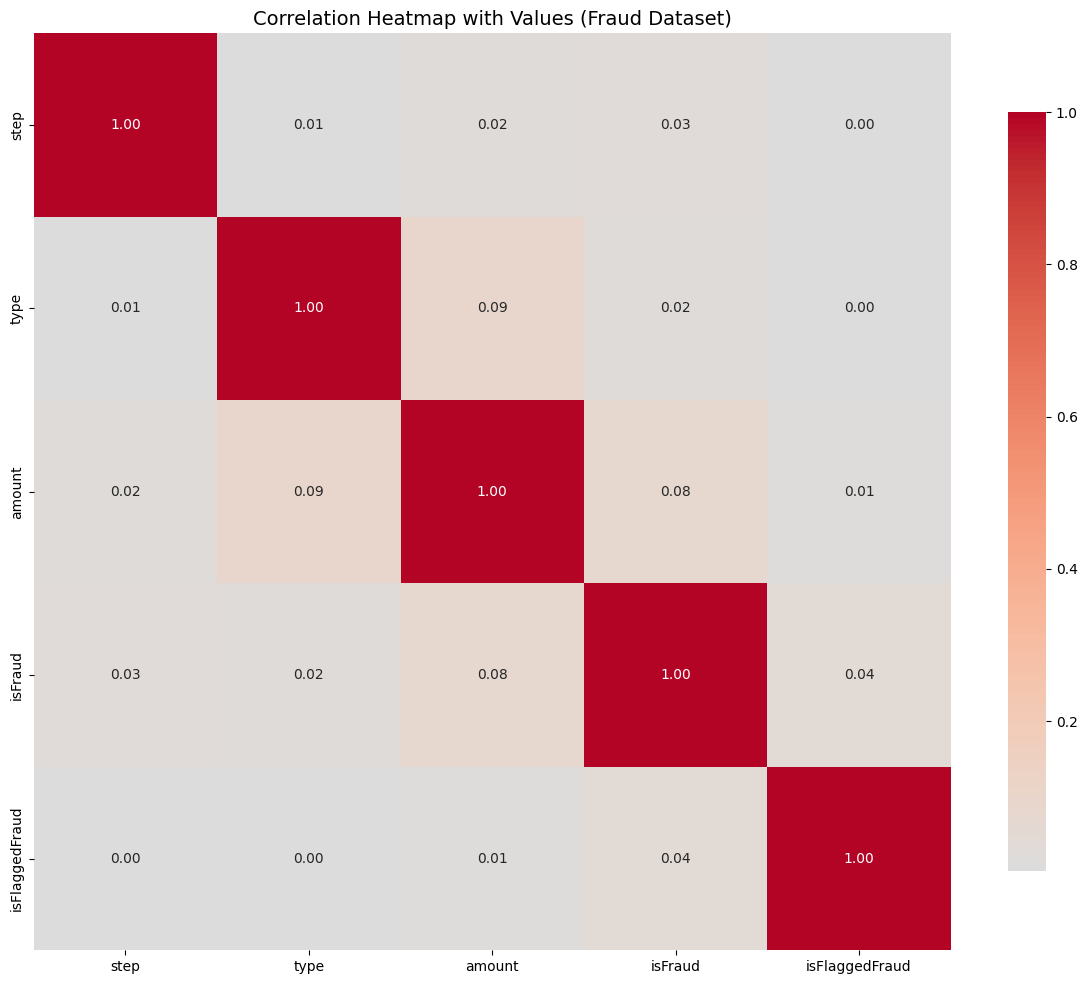

In [23]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap with Values (Fraud Dataset)", fontsize=14)
plt.tight_layout()
plt.show()

# Collinearity:

**Collinearity** (Multicollinearity) refers to when predictor variables are linearly dependent:
- Measured using **VIF (Variance Inflation Factor)**
- VIF > 5: Moderate collinearity
- VIF > 10: High collinearity (problematic for modeling)
- Considers **multiple variables** simultaneously
- Can exist even when pairwise correlations are low!

In [24]:
# Calculate VIF (Variance Inflation Factor) for Collinearity Detection
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Select numeric features for VIF calculation (excluding target variable 'isFraud')
numeric_features = df_encode.select_dtypes(include=[np.number]).columns.tolist()
if 'isFraud' in numeric_features:
    numeric_features.remove('isFraud')

# Create feature matrix for VIF calculation
X = df_encode[numeric_features].dropna()

# Calculate VIF for each feature
vif_data = []
for i in range(X.shape[1]):
    vif_value = variance_inflation_factor(X.values, i)
    vif_data.append({'Feature': X.columns[i], 'VIF': vif_value})

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF) - Collinearity Detection:")
print("="*50)
for _, row in vif_df.iterrows():
    status = ""
    if row['VIF'] > 10:
        status = "HIGH COLLINEARITY"
    elif row['VIF'] > 5:
        status = "MODERATE COLLINEARITY"
    else:
        status = "LOW COLLINEARITY"

    print(f"{row['Feature']:<15}: {row['VIF']:>8.2f} {status}")

Variance Inflation Factor (VIF) - Collinearity Detection:
type           :     1.90 LOW COLLINEARITY
step           :     1.88 LOW COLLINEARITY
amount         :     1.09 LOW COLLINEARITY
isFlaggedFraud :     1.00 LOW COLLINEARITY


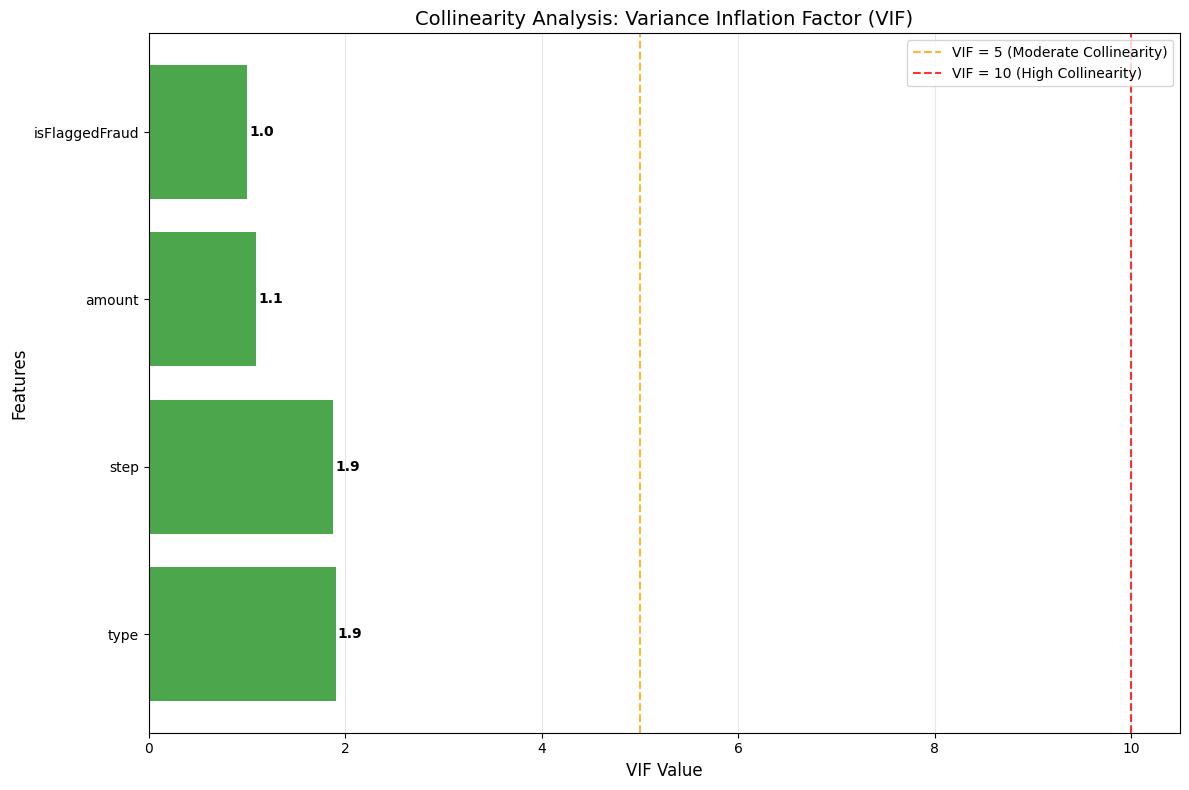


VIF Interpretation:
VIF < 5:  Low collinearity (good for modeling)
5 ≤ VIF < 10: Moderate collinearity (monitor)
VIF ≥ 10: High collinearity (consider removing)

Collinearity shows how well each variable can be predicted
from ALL other variables combined (multivariate relationship)


In [25]:
# Create VIF visualization for Collinearity
plt.figure(figsize=(12, 8))

# VIF Bar Chart
vif_colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_df['VIF']]
bars = plt.barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors, alpha=0.7)

# Add reference lines
plt.axvline(x=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5 (Moderate Collinearity)')
plt.axvline(x=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10 (High Collinearity)')

# Add VIF values on bars
for i, (bar, vif_val) in enumerate(zip(bars, vif_df['VIF'])):
    plt.text(vif_val + max(vif_df['VIF']) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{vif_val:.1f}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('VIF Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Collinearity Analysis: Variance Inflation Factor (VIF)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nVIF Interpretation:")
print("="*40)
print("VIF < 5:  Low collinearity (good for modeling)")
print("5 ≤ VIF < 10: Moderate collinearity (monitor)")
print("VIF ≥ 10: High collinearity (consider removing)")
print("\nCollinearity shows how well each variable can be predicted")
print("from ALL other variables combined (multivariate relationship)")

# Collinearity and Correlation Plot

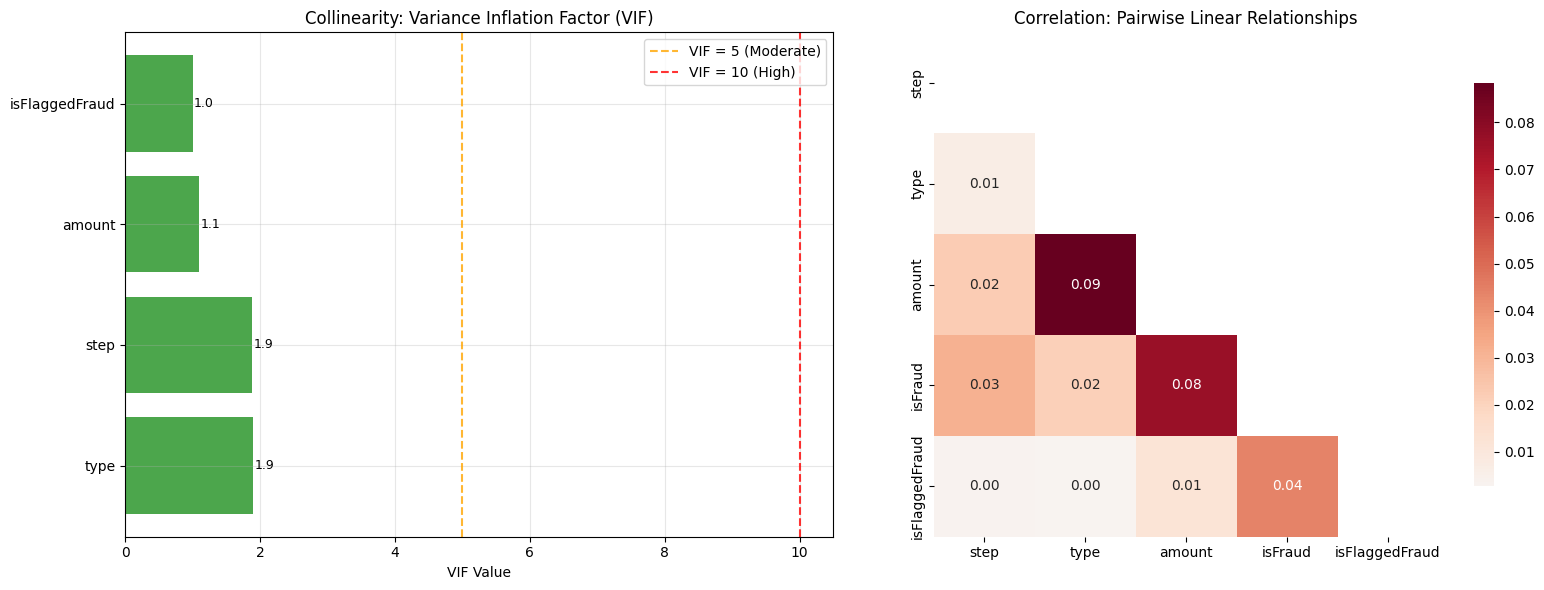


Comparison Summary:
Left plot (VIF): Shows multivariate collinearity - how well each variable
                 can be predicted from ALL other variables combined
Right plot (Correlation): Shows pairwise relationships - how each variable
                         relates to just ONE other variable at a time


In [26]:
# Create comparison plots: Correlation vs Collinearity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: VIF Bar Chart (Collinearity)
vif_colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_df['VIF']]
bars = axes[0].barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors, alpha=0.7)
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5 (Moderate)')
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10 (High)')
axes[0].set_xlabel('VIF Value')
axes[0].set_title('Collinearity: Variance Inflation Factor (VIF)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add VIF values on bars
for i, (bar, vif_val) in enumerate(zip(bars, vif_df['VIF'])):
    axes[0].text(vif_val + max(vif_df['VIF']) * 0.01, bar.get_y() + bar.get_height()/2,
                f'{vif_val:.1f}', va='center', fontsize=9)

# Plot 2: Correlation Heatmap (clean version)
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_upper, annot=True, cmap='RdBu_r', center=0,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8}, fmt='.2f')
axes[1].set_title('Correlation: Pairwise Linear Relationships')

plt.tight_layout()
plt.show()

print("\nComparison Summary:")
print("="*50)
print("Left plot (VIF): Shows multivariate collinearity - how well each variable")
print("                 can be predicted from ALL other variables combined")
print("Right plot (Correlation): Shows pairwise relationships - how each variable")
print("                         relates to just ONE other variable at a time")

Based on the above collinearity and correlation findings, the combination of variables to be taken note of are:      
- amount vs type
- isFraud vs amount


### Transaction velocity

In [27]:
# Create a 'day' variable
df['day'] = (df['step'] // 24).astype(int)

# daily transaction counts for fraud and non-fraud
fraud_daily = df[df['isFraud'] == 1].groupby('day').size().reset_index(name='fraud_count')
nonfraud_daily = df[df['isFraud'] == 0].groupby('day').size().reset_index(name='nonfraud_count')


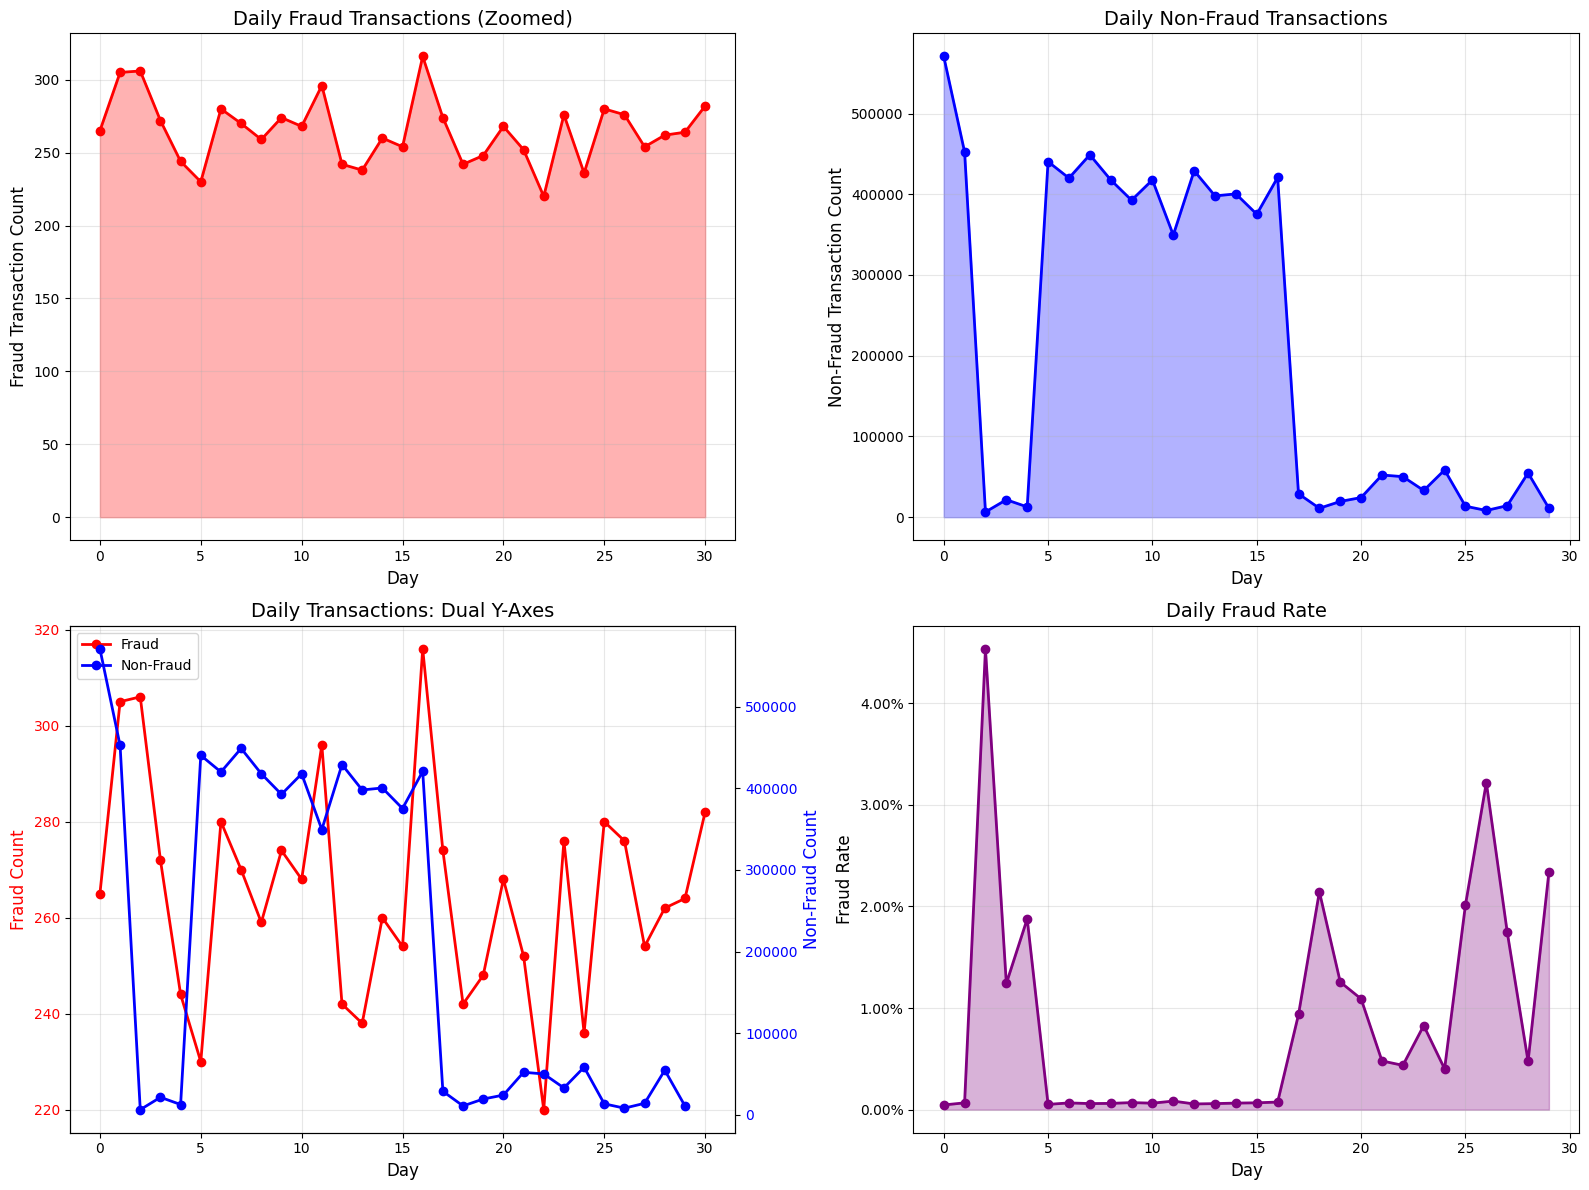

In [28]:
# visualization with dual y-axes to show both fraud and non-fraud clearly
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Fraud only (zoomed in)
axes[0, 0].plot(fraud_daily['day'], fraud_daily['fraud_count'], color='red', marker='o', linewidth=2, markersize=6)
axes[0, 0].fill_between(fraud_daily['day'], fraud_daily['fraud_count'], alpha=0.3, color='red')
axes[0, 0].set_xlabel('Day', fontsize=12)
axes[0, 0].set_ylabel('Fraud Transaction Count', fontsize=12)
axes[0, 0].set_title('Daily Fraud Transactions (Zoomed)', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Non-fraud only
axes[0, 1].plot(nonfraud_daily['day'], nonfraud_daily['nonfraud_count'], color='blue', marker='o', linewidth=2, markersize=6)
axes[0, 1].fill_between(nonfraud_daily['day'], nonfraud_daily['nonfraud_count'], alpha=0.3, color='blue')
axes[0, 1].set_xlabel('Day', fontsize=12)
axes[0, 1].set_ylabel('Non-Fraud Transaction Count', fontsize=12)
axes[0, 1].set_title('Daily Non-Fraud Transactions', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Both with dual y-axes
ax1 = axes[1, 0]
ax2 = ax1.twinx()

line1 = ax1.plot(fraud_daily['day'], fraud_daily['fraud_count'], color='red', marker='o', linewidth=2, markersize=6, label='Fraud')
line2 = ax2.plot(nonfraud_daily['day'], nonfraud_daily['nonfraud_count'], color='blue', marker='o', linewidth=2, markersize=6, label='Non-Fraud')

ax1.set_xlabel('Day', fontsize=12)
ax1.set_ylabel('Fraud Count', fontsize=12, color='red')
ax2.set_ylabel('Non-Fraud Count', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='red')
ax2.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Daily Transactions: Dual Y-Axes', fontsize=14)
ax1.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Plot 4: Fraud rate per day
fraud_rate_daily = fraud_daily.copy()
fraud_rate_daily['total'] = fraud_daily['fraud_count'] + nonfraud_daily['nonfraud_count']
fraud_rate_daily['fraud_rate'] = fraud_daily['fraud_count'] / fraud_rate_daily['total']

axes[1, 1].plot(fraud_rate_daily['day'], fraud_rate_daily['fraud_rate'], color='purple', marker='o', linewidth=2, markersize=6)
axes[1, 1].fill_between(fraud_rate_daily['day'], fraud_rate_daily['fraud_rate'], alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Day', fontsize=12)
axes[1, 1].set_ylabel('Fraud Rate', fontsize=12)
axes[1, 1].set_title('Daily Fraud Rate', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.2%}'.format(y)))

plt.tight_layout()
plt.show()

## nameDest vs amount
This pair explores recipient behavior in terms of the money they receive, uncovering hidden fraud patterns, transaction anomalies, and behavioral clustering among accounts.   


Which recipients (nameDest) receive large or irregular amounts?    
Are there outliers or concentration patterns in how funds are distributed?    
Do fraudulent transactions (if labelled) cluster around certain recipients or amount ranges?    

### Average Amount to Destination
Mean amount transferred to the same receiver (avgAmountToDest)

In [36]:
# Calculate average amount transferred to each receiver per sender
avg_amount_to_dest = (
    df.groupby(['nameOrig', 'nameDest'])['amount']
    .mean()
    .reset_index(name='avgAmountToDest')
)

# Merge back to main dataframe
df = df.merge(avg_amount_to_dest, on=['nameOrig', 'nameDest'], how='left')

print("Average Amount to Destination - Statistics:")
print(df.groupby('isFraud')['avgAmountToDest'].describe())

# Show sample
print("\nSample of avgAmountToDest:")
print(df[['nameOrig', 'nameDest', 'amount', 'avgAmountToDest', 'isFraud']].head(10))

Average Amount to Destination - Statistics:
             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  

Sample of avgAmountToDest:
      nameOrig     nameDest    amount  avgAmountToDest  isFraud
0  C1231006815  M1979787155   9839.64          9839.64        0
1  C1666544295  M2044282225   1864.28          1864.28        0
2  C1305486145   C553264065    181.00           181.00        1
3   C840083671    C38997010    181.00           181.00        1
4  C2048537720  M1230701703  11668.14         11668.14        0
5    C90045638   M573487274   7817.71          7817.71        0
6   C154988899   M40806

/tmp/ipython-input-1836845425.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['isFraud']==0]['avgAmountToDest'].dropna(),


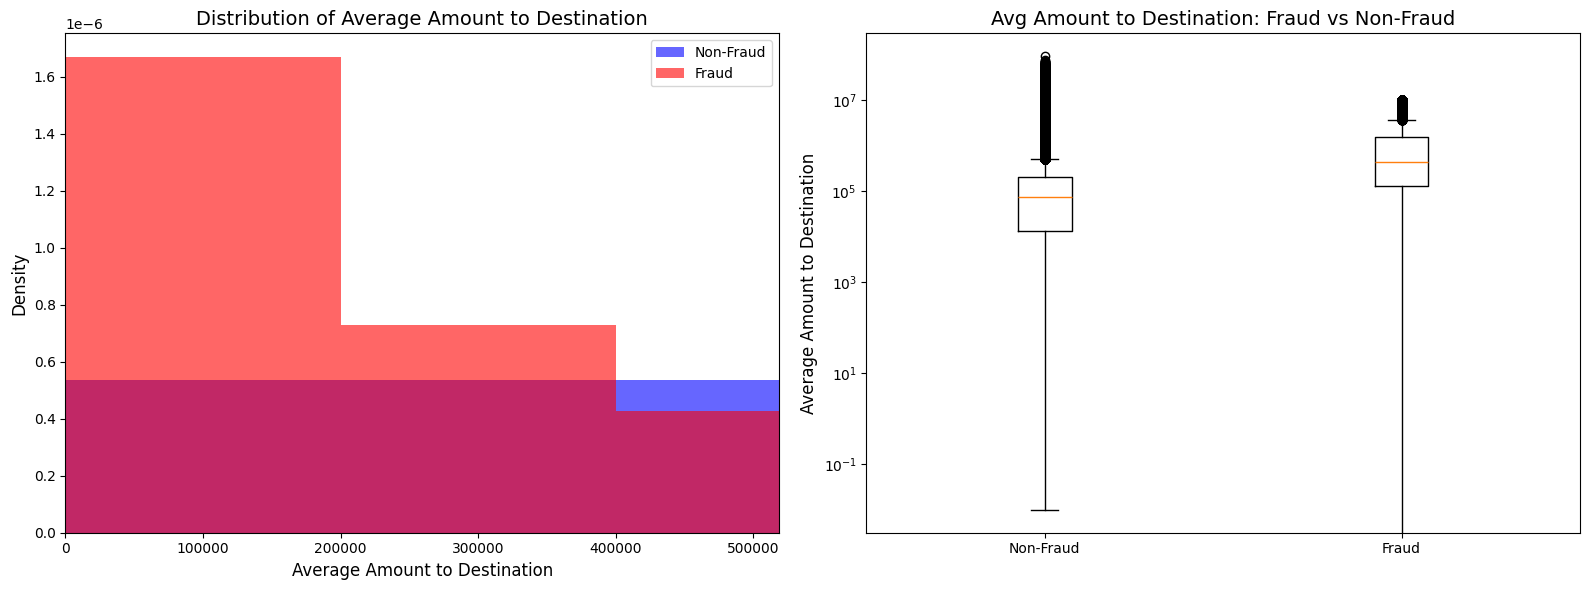

In [30]:
# Visualize average amount to destination
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Histogram comparison
axes[0].hist(df[df['isFraud']==0]['avgAmountToDest'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0].hist(df[df['isFraud']==1]['avgAmountToDest'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0].set_xlabel('Average Amount to Destination', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution of Average Amount to Destination', fontsize=14)
axes[0].legend()
axes[0].set_xlim(0, df['avgAmountToDest'].quantile(0.95))  # Focus on 95th percentile

# Plot 2: Box plot comparison
axes[1].boxplot([df[df['isFraud']==0]['avgAmountToDest'].dropna(),
                 df[df['isFraud']==1]['avgAmountToDest'].dropna()],
                labels=['Non-Fraud', 'Fraud'])
axes[1].set_ylabel('Average Amount to Destination', fontsize=12)
axes[1].set_title('Avg Amount to Destination: Fraud vs Non-Fraud', fontsize=14)
axes[1].set_yscale('log')  # Log scale due to large range

plt.tight_layout()
plt.show()

Statistics on how much money each receiver typically receives and whether they receive unusually large or small amounts compared to others

In [34]:
# Aggregate statistics per receiver
receiver_amt_stats = (
    df.groupby('nameDest')['amount']
    .agg(['max', 'std'])
    .reset_index()
    .rename(columns={'max':'maxAmountReceived', 'std':'stdAmountReceived'})
)

# Merge back
df = df.merge(receiver_amt_stats, on='nameDest', how='left')

## Top Irregular Receivers (std/mean ratio)
Receivers with high variance relative to their average inflows display unstable financial behavior, a strong laundering or mule signal.

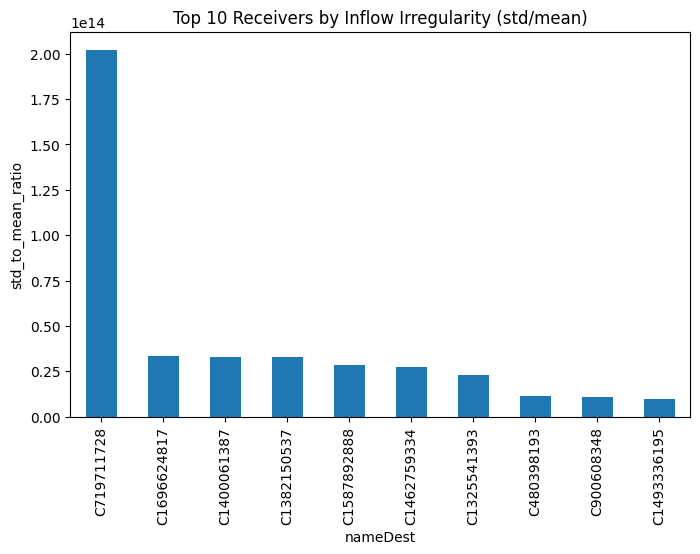

In [38]:
df['std_to_mean_ratio'] = df['stdAmountReceived'] / (df['avgAmountToDest'] + 1e-9)
top_irregular = df.groupby('nameDest')['std_to_mean_ratio'].mean().sort_values(ascending=False).head(10)

top_irregular.plot(kind='bar', figsize=(8,5), title='Top 10 Receivers by Inflow Irregularity (std/mean)')
plt.ylabel('std_to_mean_ratio')
plt.show()

In [40]:
# Get the index (nameDest) of top irregular receivers
irregular_receivers = top_irregular.index.tolist()

# Print each irregular receiver
for receiver in irregular_receivers:
    print(f"Receiver ID: {receiver}")
    
    # Get transactions for this receiver
    receiver_txns = df[df['nameDest'] == receiver]
    
    print(f"Number of transactions: {len(receiver_txns)}")
    print(f"Fraud transactions: {receiver_txns['isFraud'].sum()}")
    print(f"Fraud rate: {(receiver_txns['isFraud'].sum() / len(receiver_txns)) * 100:.2f}%")
    print("-" * 50)

Receiver ID: C719711728
Number of transactions: 6
Fraud transactions: 1
Fraud rate: 16.67%
--------------------------------------------------
Receiver ID: C1696624817
Number of transactions: 8
Fraud transactions: 1
Fraud rate: 12.50%
--------------------------------------------------
Receiver ID: C1400061387
Number of transactions: 3
Fraud transactions: 1
Fraud rate: 33.33%
--------------------------------------------------
Receiver ID: C1382150537
Number of transactions: 3
Fraud transactions: 1
Fraud rate: 33.33%
--------------------------------------------------
Receiver ID: C1587892888
Number of transactions: 4
Fraud transactions: 1
Fraud rate: 25.00%
--------------------------------------------------
Receiver ID: C1462759334
Number of transactions: 2
Fraud transactions: 1
Fraud rate: 50.00%
--------------------------------------------------
Receiver ID: C1325541393
Number of transactions: 32
Fraud transactions: 2
Fraud rate: 6.25%
--------------------------------------------------


## Account Name vs type
This pair describes what kinds of transactions (CASH_OUT, PAYMENT, TRANSFER, etc.) an account usually receives.  


Visualizing this relationship can reveal:       
Dominant transaction types per receiver and their fraud association.

### Heatmap of Accounts vs. Transaction Type
Horizontal lines with multiple strong cells indicate accounts engaged in multiple types — possible laundering intermediaries.

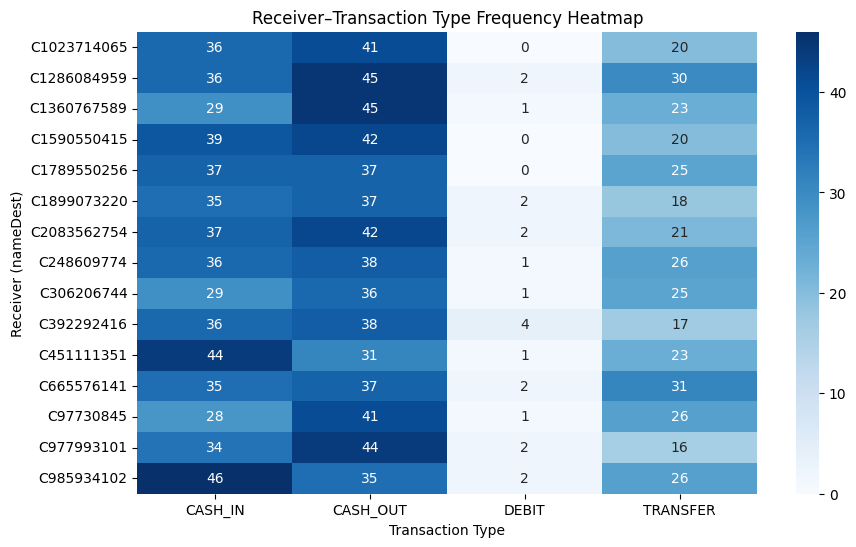

In [45]:
topN = df['nameDest'].value_counts().nlargest(15).index
subset = df[df['nameDest'].isin(topN)]

heatmap_data = pd.crosstab(subset['nameDest'], subset['type'])

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='Blues', annot=True, fmt='d')
plt.title('Receiver–Transaction Type Frequency Heatmap')
plt.xlabel('Transaction Type')
plt.ylabel('Receiver (nameDest)')
plt.show()

## amount vs type
This pair focuses on the monetary behavior of different transaction types.
Understanding how amount distributions vary by type reveals which transaction categories (e.g. CASH_OUT, TRANSFER, PAYMENT) tend to carry larger sums, wider variability, or fraud concentration.    

Which transaction types involve larger or riskier amounts?    
Do some types have tighter distributions, while others vary greatly?     
Is fraud more frequent among high-value types (e.g. TRANSFER, CASH_OUT)?

In [48]:
# Average and percentile per transaction type
type_amt_stats = (
    df.groupby('type')['amount']
    .agg(['mean', lambda x: x.quantile(0.95)])
    .reset_index()
    .rename(columns={'mean':'avgAmountPerType', '<lambda_0>':'p95AmountPerType'})
)

df = df.merge(type_amt_stats, on='type', how='left')

# Ratio and flag
df['amountTypeRatio'] = df['amount'] / (df['avgAmountPerType'] + 1e-9)
df['typeHighValueFlag'] = (df['amount'] > df['p95AmountPerType']).astype(int)

## Mean and Std per Type
Transaction types with both high mean and high std are financially volatile and may be higher risk for fraud.

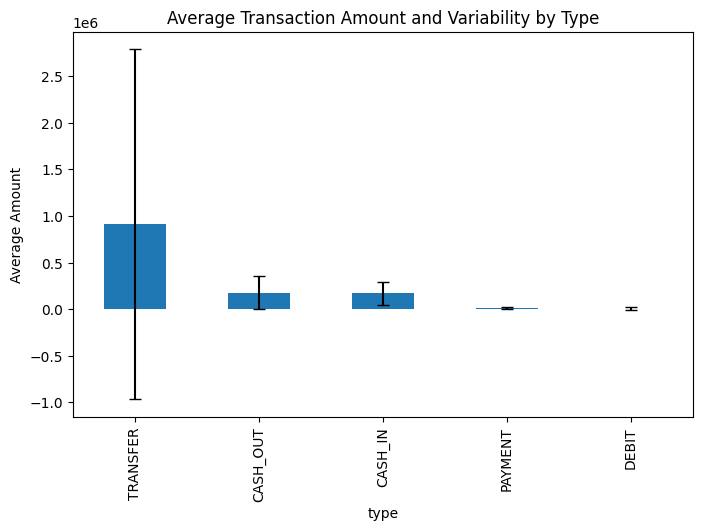

In [49]:
type_summary = df.groupby('type')['amount'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(8,5))
type_summary['mean'].plot(kind='bar', yerr=type_summary['std'], capsize=4)
plt.title('Average Transaction Amount and Variability by Type')
plt.ylabel('Average Amount')
plt.show()

## Strip Plot of Type vs Amount, Colored by Fraud
Fraudulent points (colored) tend to appear at higher amounts within certain types, particularly in TRANSFER or CASH_OUT.

c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


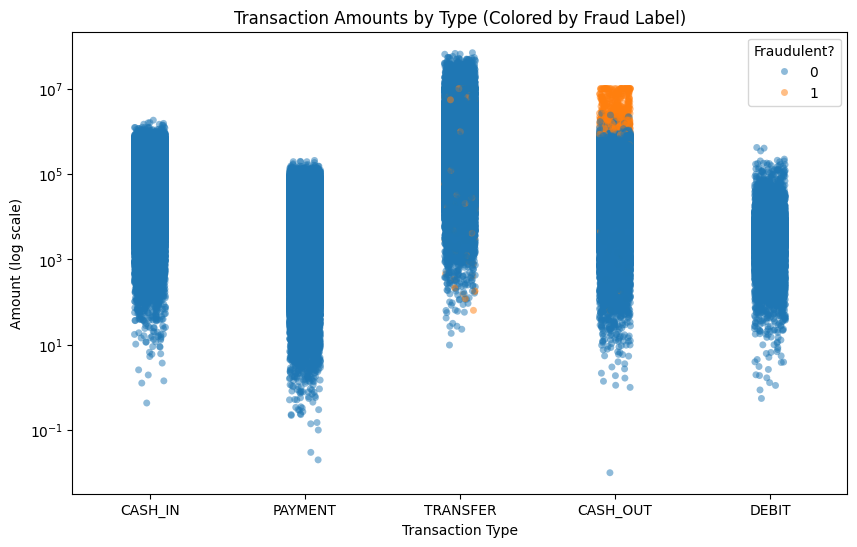

In [53]:
plt.figure(figsize=(10,6))
sns.stripplot(data=df.sample(2000000, random_state=42), x='type', y='amount', hue='isFraud', alpha=0.5)
plt.yscale('log')
plt.title('Transaction Amounts by Type (Colored by Fraud Label)')
plt.xlabel('Transaction Type')
plt.ylabel('Amount (log scale)')
plt.legend(title='Fraudulent?')
plt.show()

## isFraud vs amount
This pair connects monetary value directly with fraudulent behavior.    

How does transaction amount relate to the likelihood of fraud?    
Are fraudulent transactions concentrated in specific amount ranges (e.g., high-value transfers)?    
Can amount-based thresholds or transformations improve fraud detection?

In [54]:
# Log transform
df['amountLog'] = np.log1p(df['amount'])

# Amount binning (e.g., 10 bins)
df['amountBucket'] = pd.qcut(df['amount'], 10, duplicates='drop')

# Fraud probability by bin
fraud_rate_by_bin = df.groupby('amountBucket')['isFraud'].mean().reset_index(name='fraudProbabilityByAmountBin')
df = df.merge(fraud_rate_by_bin, on='amountBucket', how='left')

C:\Users\lylyl\AppData\Local\Temp\ipykernel_17356\3253343520.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_bin = df.groupby('amountBucket')['isFraud'].mean().reset_index(name='fraudProbabilityByAmountBin')


### Fraud Rate by Amount Bin

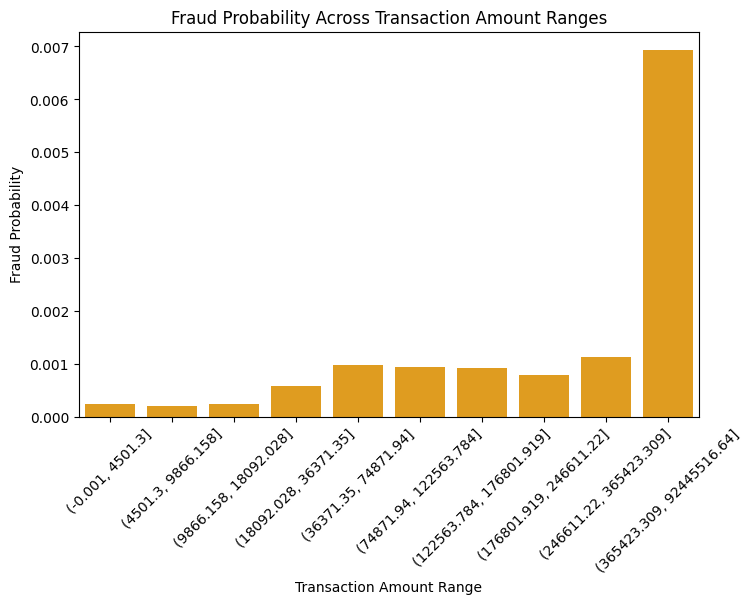

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(data=fraud_rate_by_bin, x='amountBucket', y='fraudProbabilityByAmountBin', color='orange')
plt.title('Fraud Probability Across Transaction Amount Ranges')
plt.xlabel('Transaction Amount Range')
plt.ylabel('Fraud Probability')
plt.xticks(rotation=45)
plt.show()

### Cumulative Fraud Distribution

c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


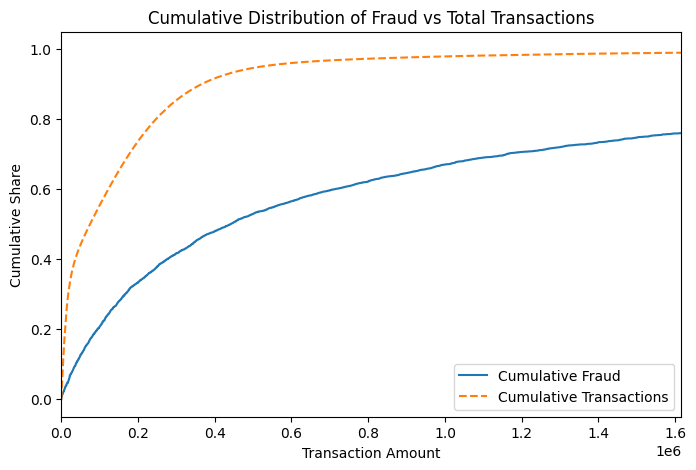

In [57]:
df_sorted = df.sort_values('amount')
cum_fraud = df_sorted['isFraud'].cumsum() / df_sorted['isFraud'].sum()
cum_trans = np.arange(len(df_sorted)) / len(df_sorted)

plt.figure(figsize=(8,5))
plt.plot(df_sorted['amount'], cum_fraud, label='Cumulative Fraud')
plt.plot(df_sorted['amount'], cum_trans, label='Cumulative Transactions', linestyle='--')
plt.title('Cumulative Distribution of Fraud vs Total Transactions')
plt.xlabel('Transaction Amount')
plt.ylabel('Cumulative Share')
plt.legend()
plt.xlim(0, df['amount'].quantile(0.99))
plt.show()


# Aggregated User Behavior Features

Aggregate statistics per user (nameOrig for senders, nameDest for receivers) to capture overall behavior patterns.

## Sender Aggregations (per nameOrig)

In [49]:
# Calculate sender aggregations
sender_agg = df.groupby('nameOrig').agg({
    'amount': ['sum', 'mean', 'std', 'count'],
    'isFraud': 'max'  # Mark sender as fraud if ANY transaction is fraud
}).reset_index()

# Flatten column names
sender_agg.columns = ['nameOrig', 'totalSent', 'meanSent', 'stdSent', 'numSent', 'sender_has_fraud']

# Calculate fraction of each transaction type per sender
type_fractions = df.groupby(['nameOrig', 'type']).size().unstack(fill_value=0)
type_fractions = type_fractions.div(type_fractions.sum(axis=1), axis=0)
type_fractions.columns = [f'fraction_{col}' for col in type_fractions.columns]
type_fractions = type_fractions.reset_index()

# Merge type fractions with sender aggregations
sender_agg = sender_agg.merge(type_fractions, on='nameOrig', how='left')

print("Sender Aggregation Features:")
print(sender_agg.head(10))
print(f"\nShape: {sender_agg.shape}")
print("\nStatistics by fraud status:")
print(sender_agg.groupby('sender_has_fraud')[['totalSent', 'meanSent', 'stdSent', 'numSent']].describe())

Sender Aggregation Features:
      nameOrig   totalSent    meanSent  stdSent  numSent  sender_has_fraud  \
0  C1000000639   244486.46   244486.46      NaN        1                 0   
1  C1000001337     3170.28     3170.28      NaN        1                 0   
2  C1000001725     8424.74     8424.74      NaN        1                 0   
3  C1000002591   261877.19   261877.19      NaN        1                 0   
4  C1000003372    20528.65    20528.65      NaN        1                 0   
5  C1000003615    49360.77    49360.77      NaN        1                 0   
6  C1000004053   211189.64   211189.64      NaN        1                 0   
7  C1000004530    93865.13    93865.13      NaN        1                 0   
8  C1000005353  3228390.11  3228390.11      NaN        1                 0   
9  C1000005555   233109.79   233109.79      NaN        1                 0   

   fraction_CASH_IN  fraction_CASH_OUT  fraction_DEBIT  fraction_PAYMENT  \
0               0.0                1

## Receiver Aggregations (per nameDest)

In [47]:
# Calculate receiver aggregations
receiver_agg = df.groupby('nameDest').agg({
    'amount': ['sum', 'mean', 'std', 'count'],
    'isFraud': 'max'  # Mark receiver as fraud if ANY transaction is fraud
}).reset_index()

# Flatten column names
receiver_agg.columns = ['nameDest', 'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'receiver_has_fraud']

# Calculate fraction of each transaction type per receiver
type_fractions_recv = df.groupby(['nameDest', 'type']).size().unstack(fill_value=0)
type_fractions_recv = type_fractions_recv.div(type_fractions_recv.sum(axis=1), axis=0)
type_fractions_recv.columns = [f'fraction_{col}_recv' for col in type_fractions_recv.columns]
type_fractions_recv = type_fractions_recv.reset_index()

# Merge type fractions with receiver aggregations
receiver_agg = receiver_agg.merge(type_fractions_recv, on='nameDest', how='left')

print("Receiver Aggregation Features:")
print(receiver_agg.head(10))
print(f"\nShape: {receiver_agg.shape}")
print("\nStatistics by fraud status:")
print(receiver_agg.groupby('receiver_has_fraud')[['totalReceived', 'meanReceived', 'stdReceived', 'numReceived']].describe())

Receiver Aggregation Features:
      nameDest  totalReceived   meanReceived    stdReceived  numReceived  \
0  C1000004082     2259324.39  376554.065000  480874.232699            6   
1  C1000004940     2534004.05  194923.388462  148169.466765           13   
2  C1000013769     6204082.94  477237.149231  558880.114944           13   
3   C100001587     1404313.66  156034.851111  143969.815113            9   
4  C1000015936     2267960.19  141747.511875   78838.151363           16   
5  C1000022185     6394585.48  399661.592500  572471.384128           16   
6  C1000026379      738061.14  184515.285000   62723.609095            4   
7  C1000030947     3511541.23  219471.326875  157501.101319           16   
8   C100003532       47143.23   47143.230000            NaN            1   
9  C1000038153     2891614.02  180725.876250  144776.225962           16   

   receiver_has_fraud  fraction_CASH_IN_recv  fraction_CASH_OUT_recv  \
0                   0               0.500000                

## Merge Aggregations Back to Main DataFrame

In [50]:
# Merge sender aggregations
df = df.merge(sender_agg, on='nameOrig', how='left')

# Merge receiver aggregations
df = df.merge(receiver_agg, on='nameDest', how='left')

print("DataFrame after merging aggregations:")
print(f"Shape: {df.shape}")
print(f"\nNew columns added: {df.shape[1] - len(df.columns) + len(sender_agg.columns) + len(receiver_agg.columns) - 2}")
print("\nSample of new features:")
print(df[['nameOrig', 'nameDest', 'totalSent', 'meanSent', 'numSent', 'totalReceived', 'meanReceived', 'numReceived', 'isFraud']].head(10))

DataFrame after merging aggregations:
Shape: (6362620, 34)

New columns added: 20

Sample of new features:
      nameOrig     nameDest  totalSent  meanSent  numSent  totalReceived  \
0  C1231006815  M1979787155    9839.64   9839.64        1        9839.64   
1  C1666544295  M2044282225    1864.28   1864.28        1        1864.28   
2  C1305486145   C553264065     181.00    181.00        1     9922784.61   
3   C840083671    C38997010     181.00    181.00        1    18017212.53   
4  C2048537720  M1230701703   11668.14  11668.14        1       11668.14   
5    C90045638   M573487274    7817.71   7817.71        1        7817.71   
6   C154988899   M408069119    7107.77   7107.77        1        7107.77   
7  C1912850431   M633326333    7861.64   7861.64        1        7861.64   
8  C1265012928  M1176932104    4024.36   4024.36        1        4024.36   
9   C712410124   C195600860    5337.77   5337.77        1     6062852.98   

    meanReceived  numReceived  isFraud  
0    9839.64000

## Fraud Ratio Among Neighbors

Calculate the percentage of connected accounts (neighbors) that have been involved in fraud.

In [54]:
# For each sender, calculate fraud ratio among receivers they've sent to
sender_neighbor_fraud = df.groupby('nameOrig').agg({
    'nameDest': 'nunique',  # Number of unique receivers
    'receiver_has_fraud': 'sum'  # Number of receivers involved in fraud
}).reset_index()
sender_neighbor_fraud.columns = ['nameOrig', 'num_receivers', 'num_fraud_receivers']
sender_neighbor_fraud['fraudRatioAmongReceivers'] = (
    sender_neighbor_fraud['num_fraud_receivers'] / sender_neighbor_fraud['num_receivers']
)

# For each receiver, calculate fraud ratio among senders they've received from
receiver_neighbor_fraud = df.groupby('nameDest').agg({
    'nameOrig': 'nunique',  # Number of unique senders
    'sender_has_fraud': 'sum'  # Number of senders involved in fraud
}).reset_index()
receiver_neighbor_fraud.columns = ['nameDest', 'num_senders', 'num_fraud_senders']
receiver_neighbor_fraud['fraudRatioAmongSenders'] = (
    receiver_neighbor_fraud['num_fraud_senders'] / receiver_neighbor_fraud['num_senders']
)

# Merge back to main dataframe
df = df.merge(sender_neighbor_fraud[['nameOrig', 'fraudRatioAmongReceivers']], on='nameOrig', how='left')
df = df.merge(receiver_neighbor_fraud[['nameDest', 'fraudRatioAmongSenders']], on='nameDest', how='left')

print("Fraud Ratio Among Neighbors:")
print("\nFor Senders (fraud ratio among their receivers):")
print(df.groupby('isFraud')['fraudRatioAmongReceivers'].describe())
print("\nFor Receivers (fraud ratio among their senders):")
print(df.groupby('isFraud')['fraudRatioAmongSenders'].describe())

Fraud Ratio Among Neighbors:

For Senders (fraud ratio among their receivers):
             count      mean       std  min  25%  50%  75%  max
isFraud                                                        
0        6354407.0  0.009041  0.094592  0.0  0.0  0.0  0.0  1.0
1           8213.0  0.998295  0.029146  0.5  1.0  1.0  1.0  1.0

For Receivers (fraud ratio among their senders):
             count      mean       std       min       25%   50%  75%  max
isFraud                                                                   
0        6354407.0  0.000715  0.010539  0.000000  0.000000  0.00  0.0  1.0
1           8213.0  0.450540  0.402743  0.011236  0.090909  0.25  1.0  1.0


## Visualizations: Sender Aggregations

C:\Users\lylyl\AppData\Local\Temp\ipykernel_6864\886770374.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])


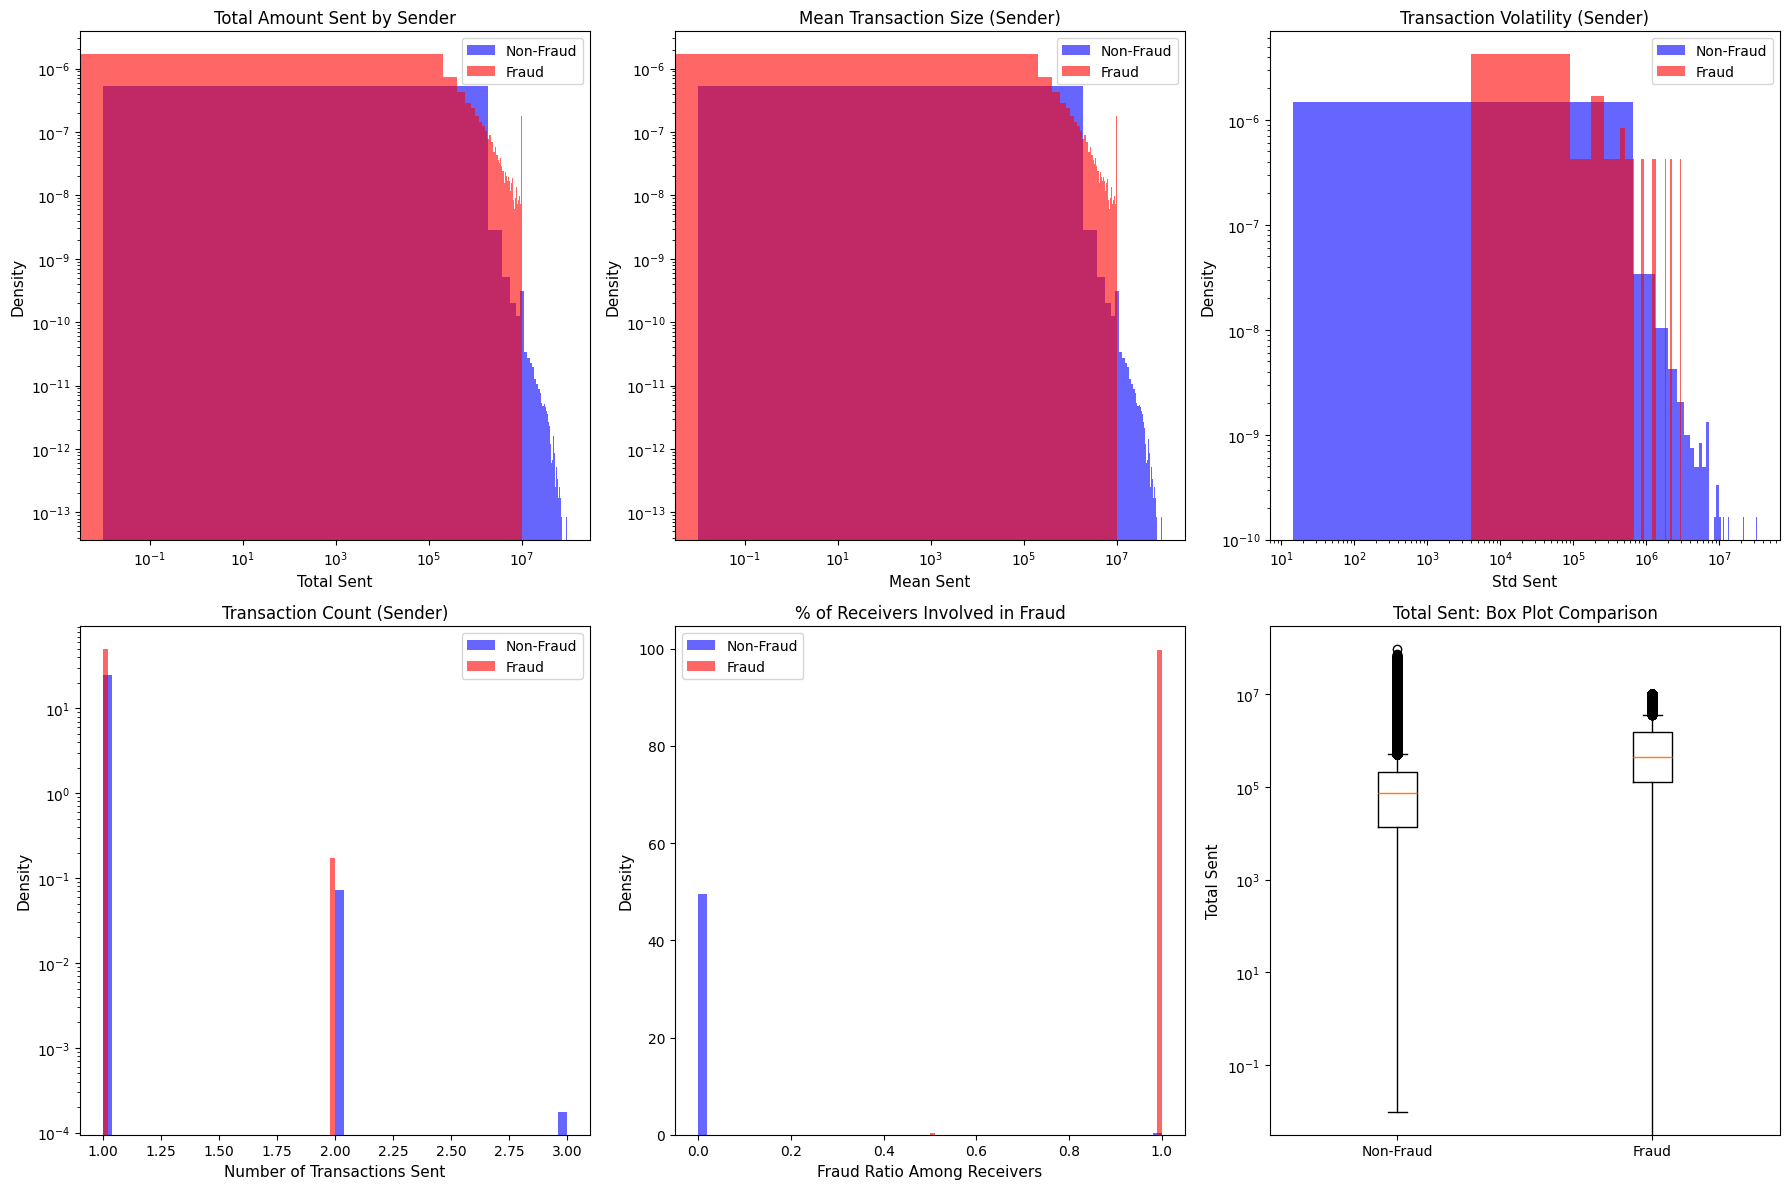

In [30]:
# Visualize sender aggregation features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Total Sent
axes[0, 0].hist(df[df['isFraud']==0]['totalSent'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 0].hist(df[df['isFraud']==1]['totalSent'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 0].set_xlabel('Total Sent', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title('Total Amount Sent by Sender', fontsize=12)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xscale('log')
axes[0, 0].legend()

# Plot 2: Mean Sent
axes[0, 1].hist(df[df['isFraud']==0]['meanSent'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 1].hist(df[df['isFraud']==1]['meanSent'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 1].set_xlabel('Mean Sent', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].set_title('Mean Transaction Size (Sender)', fontsize=12)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')
axes[0, 1].legend()

# Plot 3: Std Sent
axes[0, 2].hist(df[df['isFraud']==0]['stdSent'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 2].hist(df[df['isFraud']==1]['stdSent'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 2].set_xlabel('Std Sent', fontsize=11)
axes[0, 2].set_ylabel('Density', fontsize=11)
axes[0, 2].set_title('Transaction Volatility (Sender)', fontsize=12)
axes[0, 2].set_yscale('log')
axes[0, 2].set_xscale('log')
axes[0, 2].legend()

# Plot 4: Number of Sent Transactions
axes[1, 0].hist(df[df['isFraud']==0]['numSent'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[1, 0].hist(df[df['isFraud']==1]['numSent'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[1, 0].set_xlabel('Number of Transactions Sent', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('Transaction Count (Sender)', fontsize=12)
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Plot 5: Fraud Ratio Among Receivers
axes[1, 1].hist(df[df['isFraud']==0]['fraudRatioAmongReceivers'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[1, 1].hist(df[df['isFraud']==1]['fraudRatioAmongReceivers'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[1, 1].set_xlabel('Fraud Ratio Among Receivers', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title('% of Receivers Involved in Fraud', fontsize=12)
axes[1, 1].legend()

# Plot 6: Box plot comparison for totalSent
box_data = [df[df['isFraud']==0]['totalSent'].dropna(),
            df[df['isFraud']==1]['totalSent'].dropna()]
axes[1, 2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])
axes[1, 2].set_ylabel('Total Sent', fontsize=11)
axes[1, 2].set_title('Total Sent: Box Plot Comparison', fontsize=12)
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

## Visualizations: Receiver Aggregations

C:\Users\lylyl\AppData\Local\Temp\ipykernel_21672\1303993095.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])


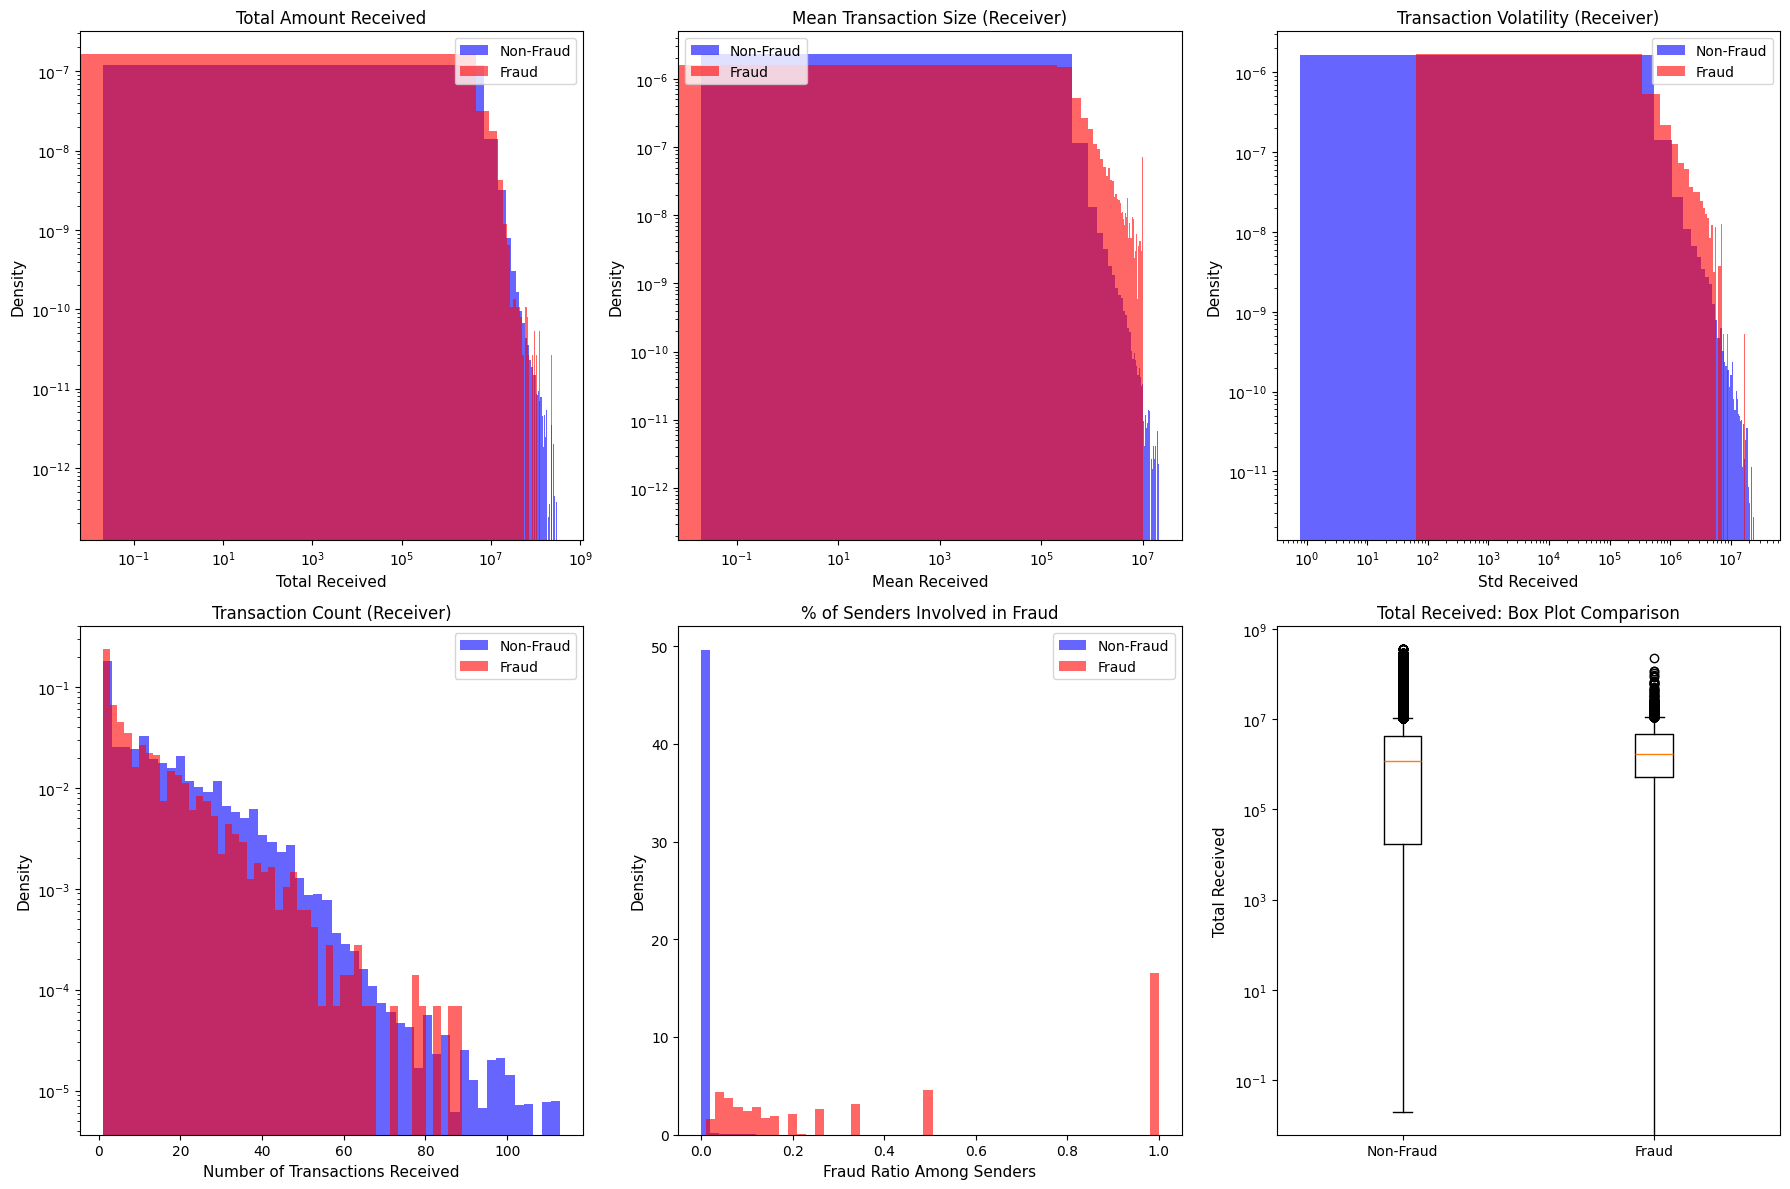

In [55]:
# Visualize receiver aggregation features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Total Received
axes[0, 0].hist(df[df['isFraud']==0]['totalReceived'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 0].hist(df[df['isFraud']==1]['totalReceived'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 0].set_xlabel('Total Received', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title('Total Amount Received', fontsize=12)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xscale('log')
axes[0, 0].legend()

# Plot 2: Mean Received
axes[0, 1].hist(df[df['isFraud']==0]['meanReceived'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 1].hist(df[df['isFraud']==1]['meanReceived'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 1].set_xlabel('Mean Received', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].set_title('Mean Transaction Size (Receiver)', fontsize=12)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')
axes[0, 1].legend()

# Plot 3: Std Received
axes[0, 2].hist(df[df['isFraud']==0]['stdReceived'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 2].hist(df[df['isFraud']==1]['stdReceived'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 2].set_xlabel('Std Received', fontsize=11)
axes[0, 2].set_ylabel('Density', fontsize=11)
axes[0, 2].set_title('Transaction Volatility (Receiver)', fontsize=12)
axes[0, 2].set_yscale('log')
axes[0, 2].set_xscale('log')
axes[0, 2].legend()

# Plot 4: Number of Received Transactions
axes[1, 0].hist(df[df['isFraud']==0]['numReceived'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[1, 0].hist(df[df['isFraud']==1]['numReceived'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[1, 0].set_xlabel('Number of Transactions Received', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('Transaction Count (Receiver)', fontsize=12)
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Plot 5: Fraud Ratio Among Senders
axes[1, 1].hist(df[df['isFraud']==0]['fraudRatioAmongSenders'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[1, 1].hist(df[df['isFraud']==1]['fraudRatioAmongSenders'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[1, 1].set_xlabel('Fraud Ratio Among Senders', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title('% of Senders Involved in Fraud', fontsize=12)
axes[1, 1].legend()

# Plot 6: Box plot comparison for totalReceived
box_data = [df[df['isFraud']==0]['totalReceived'].dropna(),
            df[df['isFraud']==1]['totalReceived'].dropna()]
axes[1, 2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])
axes[1, 2].set_ylabel('Total Received', fontsize=11)
axes[1, 2].set_title('Total Received: Box Plot Comparison', fontsize=12)
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

## Visualizations: Transaction Type Fractions

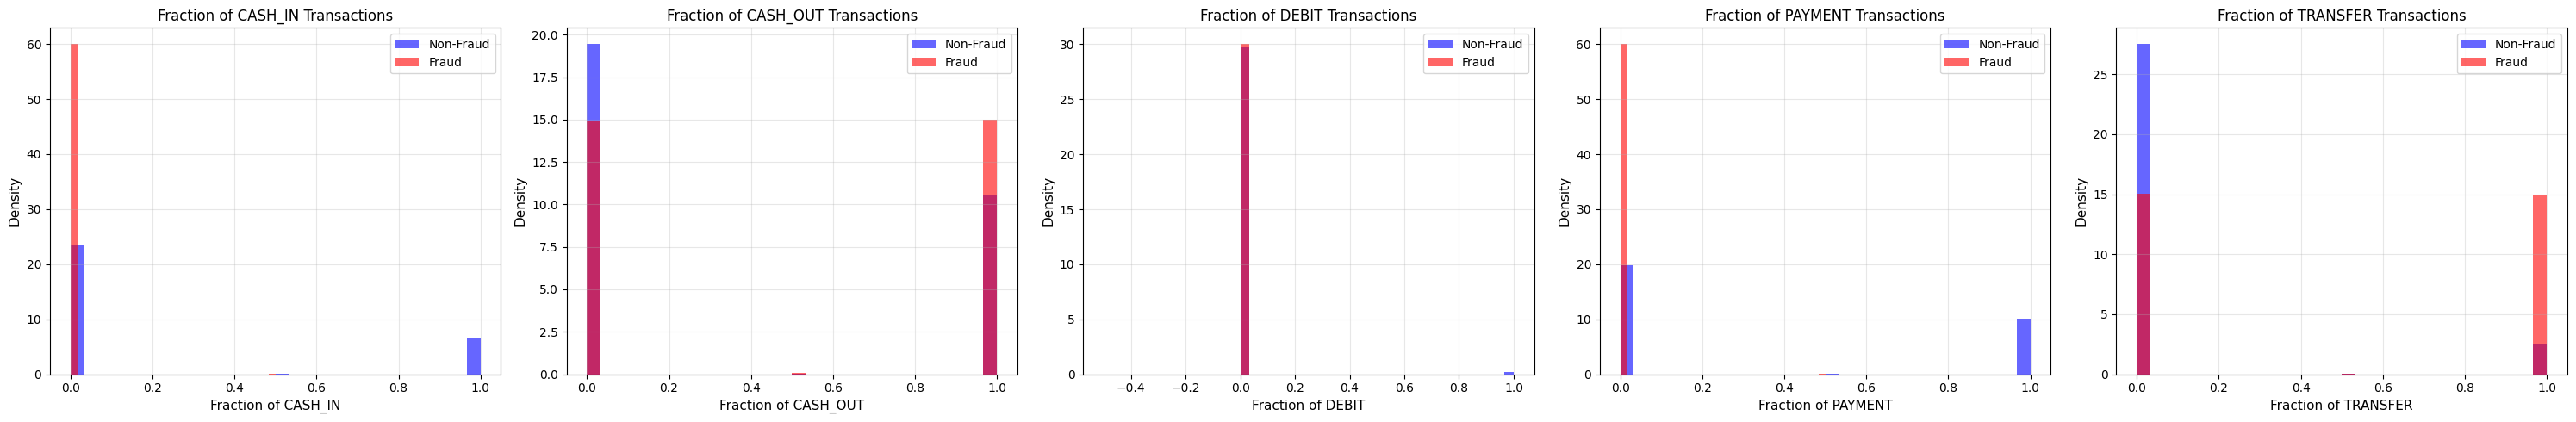

In [52]:
# Visualize transaction type fractions
# Get fraction columns
fraction_cols = [col for col in df.columns if col.startswith('fraction_') and not col.endswith('_recv')]

if len(fraction_cols) > 0:
    fig, axes = plt.subplots(1, len(fraction_cols), figsize=(6*len(fraction_cols), 5))

    if len(fraction_cols) == 1:
        axes = [axes]

    for idx, col in enumerate(fraction_cols):
        # Extract transaction type name
        txn_type = col.replace('fraction_', '')

        # Plot histogram
        axes[idx].hist(df[df['isFraud']==0][col].dropna(), bins=30, alpha=0.6, label='Non-Fraud', color='blue', density=True)
        axes[idx].hist(df[df['isFraud']==1][col].dropna(), bins=30, alpha=0.6, label='Fraud', color='red', density=True)
        axes[idx].set_xlabel(f'Fraction of {txn_type}', fontsize=11)
        axes[idx].set_ylabel('Density', fontsize=11)
        axes[idx].set_title(f'Fraction of {txn_type} Transactions', fontsize=12)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No transaction type fraction columns found")

## Time-based Feature Engineering: hourOfDay and dayOfWeek

In [43]:
#already have df['day'] = df['step']//24,
df['hourOfDay'] = df['step'] % 24
df['dayOfWeek'] = (df['step'] // 24) % 7

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['dayOfWeekName'] = df['dayOfWeek'].map({i:day_labels[i] for i in range(7)})

print("Sample of step → hourOfDay, dayOfWeek, dayOfWeekName:")
display(df[['step','hourOfDay','dayOfWeek','dayOfWeekName']].head(10))


Sample of step → hourOfDay, dayOfWeek, dayOfWeekName:


,step,hourOfDay,dayOfWeek,dayOfWeekName
0,1,1,0,Mon
1,1,1,0,Mon
2,1,1,0,Mon
3,1,1,0,Mon
4,1,1,0,Mon
5,1,1,0,Mon
6,1,1,0,Mon
7,1,1,0,Mon
8,1,1,0,Mon
9,1,1,0,Mon


## Visualizations: Time-based trends

Fraud Rate by Hour of Day (normalised for transaction volume)

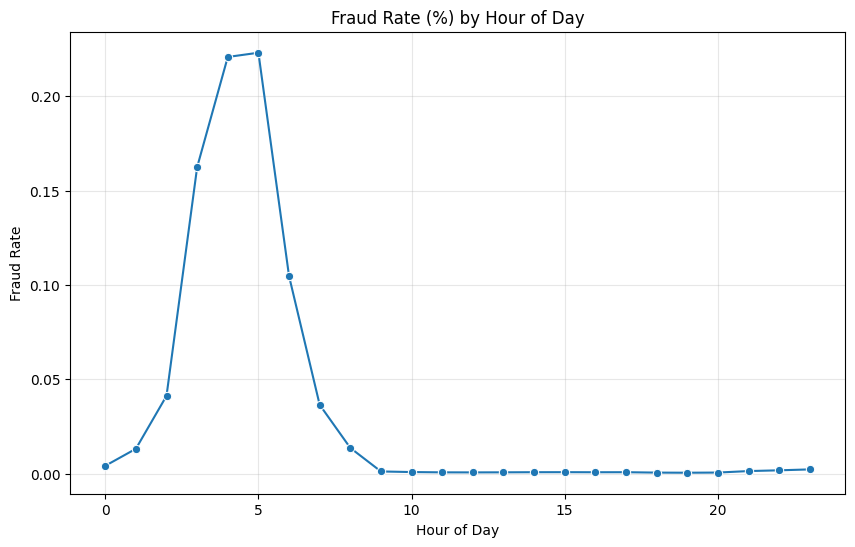

In [15]:
fraud_rate_hour = df.groupby('hourOfDay')['isFraud'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=fraud_rate_hour, x='hourOfDay', y='isFraud', marker='o')
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.grid(True, alpha=0.3)
plt.show()


Fraud Rate by Day of Week

C:\Users\lylyl\AppData\Local\Temp\ipykernel_21672\610136244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_rate_day, x='dayOfWeekName', y='isFraud', palette='magma', order=day_order)


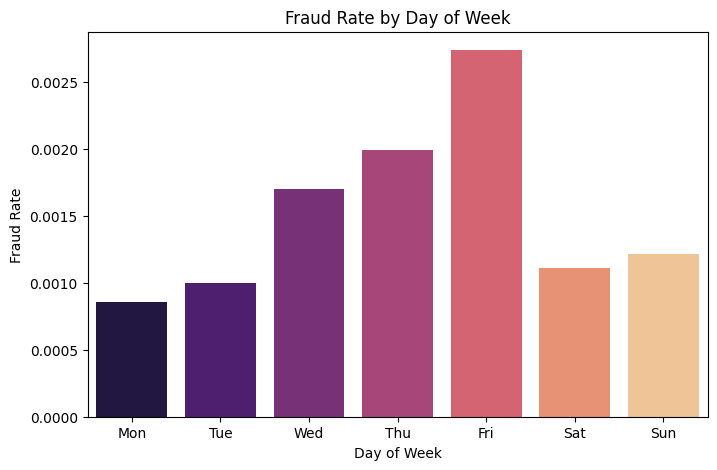

In [44]:
fraud_rate_day = df.groupby('dayOfWeekName')['isFraud'].mean().reset_index()

# enforce weekday ordering
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fraud_rate_day['dayOfWeekName'] = pd.Categorical(fraud_rate_day['dayOfWeekName'],
                                                 categories=day_order, ordered=True)
fraud_rate_day = fraud_rate_day.sort_values('dayOfWeekName')

plt.figure(figsize=(8,5))
sns.barplot(data=fraud_rate_day, x='dayOfWeekName', y='isFraud', palette='magma', order=day_order)
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate')
plt.show()

Heatmap of Fraud Rate by Day + Hour

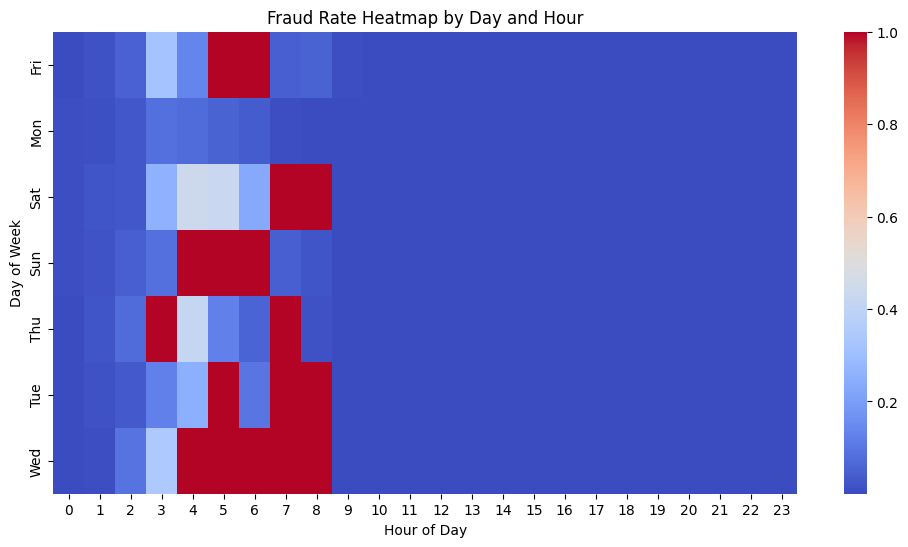

In [45]:
fraud_pivot = df.pivot_table(
    index='dayOfWeekName',
    columns='hourOfDay',
    values='isFraud',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(fraud_pivot, cmap='coolwarm', annot=False)
plt.title('Fraud Rate Heatmap by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()


Red zones = "hot spots"

In [13]:

df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'day', 'transactionFrequency_day',
       'transactionFrequency', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName'],
      dtype='object')